# Parameter Optimization — Gradient, GA & CMA-ES

This example uses the **LMTL marine ecosystem model**. If you're unfamiliar with it, see [LMTL Model — No Transport](../04_lmtl_no_transport/). Otherwise, read on — the focus here is on **optimization methods**, not the model itself.

SeapoPym supports three families of optimizers. This notebook compares them on the
same **twin experiment** (0D LMTL model, 3 parameters, clean & noisy observations).

| Optimizer           | Type              | Gradients      | Library |
| ------------------- | ----------------- | -------------- | ------- |
| **Gradient Descent**| First-order       | Required       | Optax   |
| **Genetic Algorithm** (GA) | Evolutionary | Not required | evosax  |
| **CMA-ES**          | Evolutionary      | Not required   | evosax  |

In [1]:
import time

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import seapopym.functions.lmtl  # noqa: F401 — register LMTL physics functions
from seapopym.blueprint import Config
from seapopym.compiler import compile_model
from seapopym.engine import build_step_fn, run
from seapopym.models import LMTL_NO_TRANSPORT
from seapopym.optimization import (
    CMAESOptimizer,
    GAOptimizer,
    GradientOptimizer,
    Objective,
)
from seapopym.optimization.prior import PriorSet

PALETTE = ["#1B4965", "#62B6CB", "#E8833A", "#5FA8D3"]
COLORS = {"Gradient": PALETTE[0], "GA": PALETTE[2], "CMA-ES": PALETTE[1]}
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3})

## 1. Twin Experiment Setup

A **twin experiment** validates an optimizer by running the model with known
parameters, extracting synthetic observations, then optimizing from **wrong initial
guesses** to recover the truth.

We optimize **3 parameters** (the others stay fixed at their true values):

| Parameter      | Description                            | True Value | Initial Guess (50%) |
| -------------- | -------------------------------------- | ---------- | ------------------- |
| `efficiency`   | NPP transfer efficiency                | 0.1668     | 0.0834              |
| `gamma_lambda` | Thermal sensitivity of mortality       | 0.15 /°C   | 0.075               |
| `gamma_tau_r`  | Thermal sensitivity of recruitment age | 0.11 /°C   | 0.055               |


In [2]:
# --- True parameter values ---
TRUE_PARAMS = {
    "lambda_0": 1 / 150 / 86400,
    "gamma_lambda": 0.15,
    "tau_r_0": 10.38 * 86400,
    "gamma_tau_r": 0.11,
    "efficiency": 0.1668,
    "t_ref": 0.0,
}

# Parameters to optimize
OPT_PARAM_NAMES = ["efficiency", "gamma_lambda", "gamma_tau_r"]
BOUNDS = {
    "efficiency": (0.01, 5 * TRUE_PARAMS["efficiency"]),
    "gamma_lambda": (0.01, 5 * TRUE_PARAMS["gamma_lambda"]),
    "gamma_tau_r": (0.01, 5 * TRUE_PARAMS["gamma_tau_r"]),
}

# Initial guesses: 50% of true values
INIT_PARAMS = {k: 0.5 * TRUE_PARAMS[k] for k in OPT_PARAM_NAMES}

# Time setup
SPINUP_YEARS = 1
OPT_YEARS = 2
DT = "1d"
OBS_FRACTION = 0.10
SEED = 42
NOISE_LEVELS = [0.0, 0.15]

## 2. Model & Observations

We compile the `LMTL_NO_TRANSPORT` blueprint on a 1×1 grid with seasonal forcings, then generate synthetic observations (10% of timesteps) from a run with true parameters. See [LMTL Model — No Transport](../04_lmtl_no_transport/) for details on the model setup.

In [3]:
blueprint = LMTL_NO_TRANSPORT

# Time
total_years = SPINUP_YEARS + OPT_YEARS
start_date = "2000-01-01"
end_date = str((pd.Timestamp(start_date) + pd.DateOffset(years=total_years)).date())
dates = pd.date_range(
    start=pd.to_datetime(start_date), periods=(pd.to_datetime(end_date) - pd.to_datetime(start_date)).days + 5, freq="D"
)
doy = dates.dayofyear.values.astype(float)

# Grid (1×1), cohorts
ny, nx = 1, 1
lat, lon = np.arange(ny), np.arange(nx)
max_age_days = int(np.ceil(TRUE_PARAMS["tau_r_0"] * 5 / 86400))
cohort_ages_sec = np.arange(0, max_age_days + 1) * 86400.0

# Seasonal forcings
temp_c = 15.0 + 5.0 * np.sin(2 * np.pi * doy / 365.0)
temp_4d = np.broadcast_to(temp_c[:, None, None, None], (len(dates), 1, ny, nx))
npp_sec = (1.0 + 0.5 * np.sin(2 * np.pi * doy / 365.0)) / 86400.0
npp_3d = np.broadcast_to(npp_sec[:, None, None], (len(dates), ny, nx))

# Config with perturbed initial guesses
config = Config(
    parameters={
        "lambda_0": xr.DataArray([TRUE_PARAMS["lambda_0"]], dims=["F"]),
        "gamma_lambda": xr.DataArray([INIT_PARAMS["gamma_lambda"]], dims=["F"]),
        "tau_r_0": xr.DataArray([TRUE_PARAMS["tau_r_0"]], dims=["F"]),
        "gamma_tau_r": xr.DataArray([INIT_PARAMS["gamma_tau_r"]], dims=["F"]),
        "t_ref": xr.DataArray(TRUE_PARAMS["t_ref"]),
        "efficiency": xr.DataArray([INIT_PARAMS["efficiency"]], dims=["F"]),
        "cohort_ages": xr.DataArray(cohort_ages_sec, dims=["C"]),
        "day_layer": xr.DataArray([0], dims=["F"]),
        "night_layer": xr.DataArray([0], dims=["F"]),
    },
    forcings={
        "latitude": xr.DataArray(np.full(ny, 30.0), dims=["Y"], coords={"Y": lat}),
        "temperature": xr.DataArray(
            temp_4d, dims=["T", "Z", "Y", "X"], coords={"T": dates, "Z": np.arange(1), "Y": lat, "X": lon}
        ),
        "primary_production": xr.DataArray(npp_3d, dims=["T", "Y", "X"], coords={"T": dates, "Y": lat, "X": lon}),
        "day_of_year": xr.DataArray(doy, dims=["T"], coords={"T": dates}),
    },
    initial_state={
        "biomass": xr.DataArray(np.zeros((1, ny, nx)), dims=["F", "Y", "X"], coords={"Y": lat, "X": lon}),
        "production": xr.DataArray(
            np.zeros((1, len(cohort_ages_sec), ny, nx)), dims=["F", "C", "Y", "X"], coords={"Y": lat, "X": lon}
        ),
    },
    execution={"time_start": start_date, "time_end": end_date, "dt": DT, "forcing_interpolation": "linear"},
)

model = compile_model(blueprint, config)
step_fn = build_step_fn(model, export_variables=["biomass"])
spinup_steps = int(SPINUP_YEARS / total_years * model.n_timesteps)
dt_sec = model.dt

print(f"Model: {model.n_timesteps} timesteps ({spinup_steps} spin-up, dt={dt_sec:.0f}s)")

Model: 1096 timesteps (365 spin-up, dt=86400s)


In [4]:
# Generate observations with TRUE parameters
true_params_jax = {k: jnp.array([TRUE_PARAMS[k]]) for k in OPT_PARAM_NAMES}
_, outputs_true = run(step_fn, model, dict(model.state), {**model.parameters, **true_params_jax})

biomass_true = outputs_true["biomass"]
true_ts_full = jnp.mean(biomass_true, axis=tuple(range(1, biomass_true.ndim)))
true_ts = true_ts_full[spinup_steps:]
n_opt_steps = len(true_ts)

# Sample 10% of timesteps as observations
rng = np.random.default_rng(SEED)
n_obs = max(2, int(OBS_FRACTION * n_opt_steps))
obs_local_idx = np.sort(rng.choice(n_opt_steps, size=n_obs, replace=False))
obs_global_idx = obs_local_idx + spinup_steps
obs_clean = np.array(true_ts[obs_local_idx])
time_days = np.arange(n_opt_steps) * dt_sec / 86400.0

print(f"Observations: {n_obs} points ({100 * n_obs / n_opt_steps:.0f}% of timesteps)")

Observations: 73 points (10% of timesteps)


In [5]:
def extract_predictions(outputs):
    """Extract biomass at observation timesteps."""
    biomass = outputs["biomass"]
    ts = jnp.mean(biomass, axis=tuple(range(1, biomass.ndim)))
    return ts[obs_global_idx]

## 3. Run Optimizers

We run all three optimizers on both clean and noisy (15%) observations.

- **Gradient** (Adam): 300 steps, differentiates through the full simulation via `jax.value_and_grad`
- **GA** (SimpleGA): 150 generations, population of 64
- **CMA-ES**: 150 generations, population of 32 — learns the search covariance matrix adaptively

In [6]:
all_results = {}  # {(noise_level, method_name): {"result": ..., "elapsed": ...}}

for noise_level in NOISE_LEVELS:
    noise_label = "clean" if noise_level == 0.0 else f"noise={noise_level:.0%}"

    if noise_level > 0:
        noise_rng = np.random.default_rng(SEED + 1)
        obs_values = jnp.array(obs_clean + noise_rng.normal(0, noise_level * np.abs(obs_clean)))
    else:
        obs_values = jnp.array(obs_clean)

    objective = Objective(observations=obs_values, transform=extract_predictions)

    # Gradient (Adam)
    opt_grad = GradientOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),
        algorithm="adam",
        learning_rate=0.01,
        scaling="bounds",
        export_variables=["biomass"],
    )
    t0 = time.time()
    res_grad = opt_grad.run(model, n_steps=300, tolerance=1e-8, progress_bar=False)
    all_results[(noise_level, "Gradient")] = {"result": res_grad, "elapsed": time.time() - t0}

    # GA
    opt_ga = GAOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),
        popsize=64,
        seed=SEED,
        export_variables=["biomass"],
    )
    t0 = time.time()
    res_ga = opt_ga.run(model, n_generations=150, patience=50, progress_bar=False)
    all_results[(noise_level, "GA")] = {"result": res_ga, "elapsed": time.time() - t0}

    # CMA-ES
    opt_cmaes = CMAESOptimizer(
        objectives=[(objective, "mse", 1.0)],
        bounds=BOUNDS,
        priors=PriorSet({}),
        popsize=32,
        seed=SEED,
        export_variables=["biomass"],
    )
    t0 = time.time()
    res_cmaes = opt_cmaes.run(model, n_generations=150, patience=50, progress_bar=False)
    all_results[(noise_level, "CMA-ES")] = {"result": res_cmaes, "elapsed": time.time() - t0}

# Timing summary
METHODS = ["Gradient", "GA", "CMA-ES"]
print(f"{'Method':<12} {'Clean':>8} {'Noisy':>8}")
print(f"{'-' * 28}")
for m in METHODS:
    t_clean = all_results[(0.0, m)]["elapsed"]
    t_noisy = all_results[(0.15, m)]["elapsed"]
    print(f"{m:<12} {t_clean:>7.1f}s {t_noisy:>7.1f}s")

Method          Clean    Noisy
----------------------------
Gradient        40.7s    43.8s
GA               1.3s     0.8s
CMA-ES           1.1s     0.9s


## 4. Results

For each noise level, we compare:
1. **Loss convergence** — gradient steps vs evolutionary generations
2. **Parameter recovery** — ratio of optimized / true value
3. **Biomass fit** — true trajectory vs each optimizer's prediction

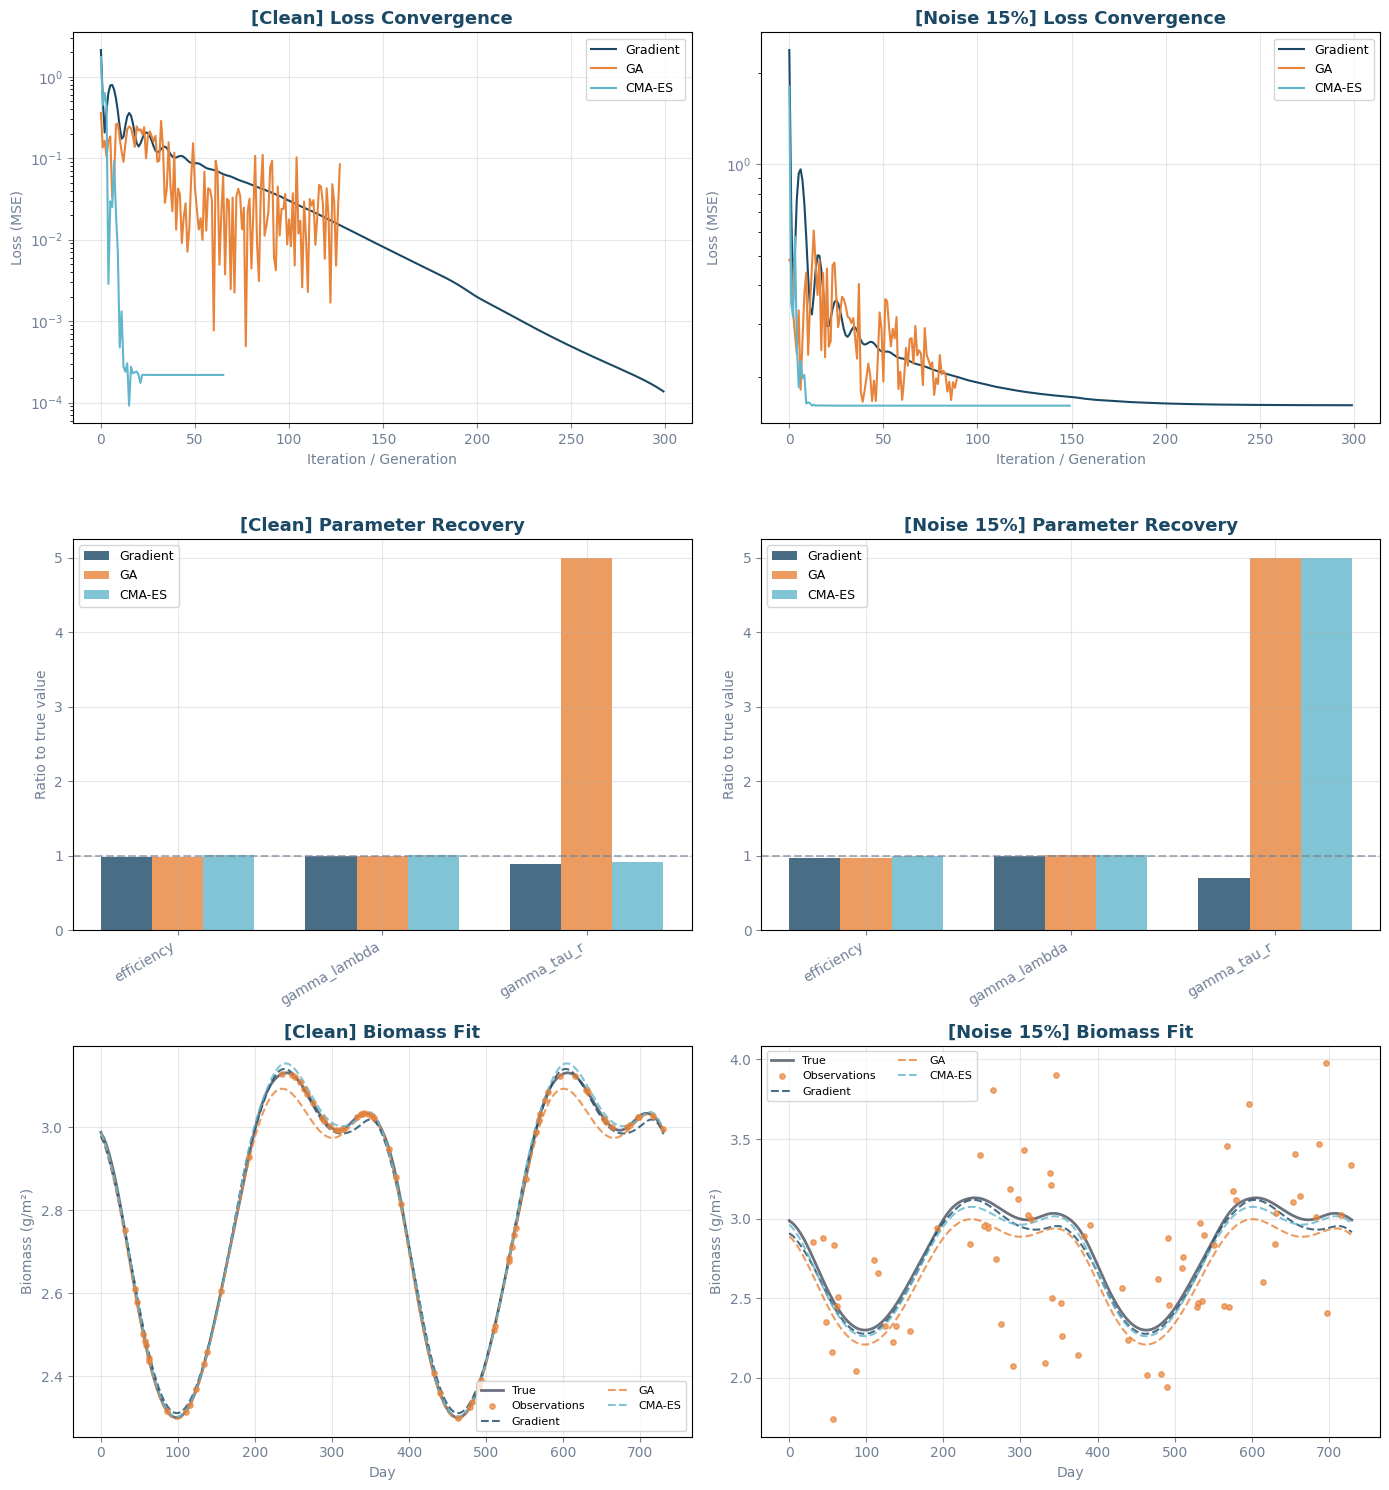

In [7]:
n_noise = len(NOISE_LEVELS)

fig, axes = plt.subplots(3, n_noise, figsize=(7 * n_noise, 5 * 3))

for col, noise_level in enumerate(NOISE_LEVELS):
    noise_label = "Clean" if noise_level == 0.0 else f"Noise {noise_level:.0%}"

    # Prepare noisy observations for scatter
    if noise_level > 0:
        noise_rng = np.random.default_rng(SEED + 1)
        obs_values = obs_clean + noise_rng.normal(0, noise_level * np.abs(obs_clean))
    else:
        obs_values = obs_clean

    # --- Row 0: Loss convergence ---
    ax = axes[0, col]
    for method in METHODS:
        res = all_results[(noise_level, method)]["result"]
        ax.semilogy(res.loss_history, color=COLORS[method], linewidth=1.5, label=method)
    ax.set_xlabel("Iteration / Generation", color="#718096")
    ax.set_ylabel("Loss (MSE)", color="#718096")
    ax.set_title(f"[{noise_label}] Loss Convergence", color="#1B4965", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.tick_params(colors="#718096")

    # --- Row 1: Parameter recovery ---
    ax = axes[1, col]
    x = np.arange(len(OPT_PARAM_NAMES))
    width = 0.25
    for i, method in enumerate(METHODS):
        res = all_results[(noise_level, method)]["result"]
        ratios = [float(jnp.squeeze(res.params[p])) / TRUE_PARAMS[p] for p in OPT_PARAM_NAMES]
        ax.bar(x + i * width, ratios, width, label=method, color=COLORS[method], alpha=0.8)
    ax.axhline(y=1, color="#718096", linestyle="--", alpha=0.6)
    ax.set_xticks(x + width)
    ax.set_xticklabels(OPT_PARAM_NAMES, rotation=30, ha="right")
    ax.set_ylabel("Ratio to true value", color="#718096")
    ax.set_title(f"[{noise_label}] Parameter Recovery", color="#1B4965", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.tick_params(colors="#718096")

    # --- Row 2: Biomass fit ---
    ax = axes[2, col]
    ax.plot(time_days, np.array(true_ts), "-", color="#2D3748", linewidth=2, label="True", alpha=0.7)
    ax.scatter(
        obs_local_idx * dt_sec / 86400.0,
        obs_values,
        c=PALETTE[2],
        s=15,
        zorder=5,
        label="Observations",
        alpha=0.7,
    )
    for method in METHODS:
        res = all_results[(noise_level, method)]["result"]
        _, out = run(step_fn, model, dict(model.state), {**model.parameters, **res.params})
        bio = out["biomass"]
        ts = jnp.mean(bio, axis=tuple(range(1, bio.ndim)))[spinup_steps:]
        ax.plot(time_days, np.array(ts), "--", color=COLORS[method], linewidth=1.5, label=method, alpha=0.8)
    ax.set_xlabel("Day", color="#718096")
    ax.set_ylabel("Biomass (g/m²)", color="#718096")
    ax.set_title(f"[{noise_label}] Biomass Fit", color="#1B4965", fontsize=13, fontweight="bold")
    ax.legend(fontsize=8, ncol=2)
    ax.tick_params(colors="#718096")

fig.tight_layout()
plt.show()

## Summary

|                      | Gradient (Adam)               | GA                        | CMA-ES                   |
| -------------------- | ----------------------------- | ------------------------- | ------------------------ |
| **Type**             | First-order gradient          | Evolutionary              | Evolutionary             |
| **Gradients**        | Yes (`jax.value_and_grad`)    | No                        | No                       |
| **Wall time (clean)**| ~42s (300 steps)              | ~1.3s (128 gen)           | ~1.1s (66 gen)           |
| **Best loss (clean)**| 1.3e-04                       | 4.9e-04                   | **9.2e-05**              |

**Key takeaways:**

- **CMA-ES** achieves the best loss in the shortest wall time. Evolutionary methods
  evaluate entire populations in parallel (via `jax.vmap`), which makes each generation
  much cheaper than a single gradient forward+backward pass.
- **Gradient descent** gives precise recovery on sensitive parameters (`efficiency`,
  `gamma_lambda`) but is ~40x slower and struggles with weakly sensitive ones.
- `gamma_tau_r` is hard to recover for all methods — GA and CMA-ES hit the upper
  bound on noisy data. This parameter has weak sensitivity in this configuration.

**Next**: [LMTL Model — No Transport](../04_lmtl_no_transport/) — run the marine ecosystem model that was optimized here.